(222085, 843) (222085,)
              precision    recall  f1-score   support

         0.0       0.92      0.91      0.92      8069
         1.0       0.91      0.92      0.92      7157
         2.0       0.68      0.58      0.63      5061
         3.0       0.90      0.94      0.92     21544
         4.0       0.94      0.89      0.91      2586

    accuracy                           0.89     44417
   macro avg       0.87      0.85      0.86     44417
weighted avg       0.88      0.89      0.89     44417

Overall Accuracy:  0.8882635027129252
Classwise Accuracy:  [0.91473541 0.91896046 0.58229599 0.93924062 0.89481825]


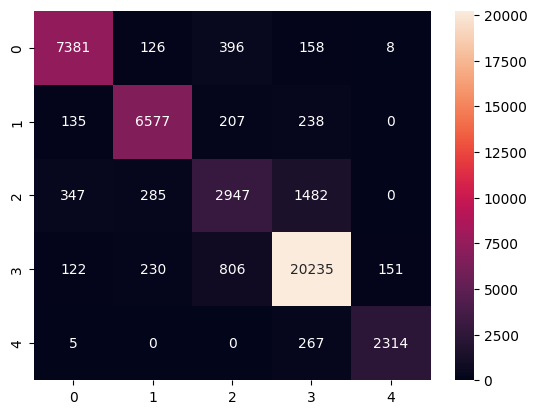

In [4]:
import pickle
import os
import numpy as np

save_dir = "/home/honeynaps/data/dataset/FEATURES/SLEEP_100_NOFILL"
x, y = [], []

saved_files = os.listdir(save_dir)
for file in saved_files:
    with open(os.path.join(save_dir, file), "rb") as f:
        data = pickle.load(f)
        x.append(data["x"])
        y.append(data["y"])

x = np.concatenate(x)
y = np.concatenate(y)

print(x.shape, y.shape)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


clf = XGBClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
overall_acc = np.trace(cm) / np.sum(cm)
classwise_acc = np.diag(cm) / np.sum(cm, axis=1)

print("Overall Accuracy: ", overall_acc)
print("Classwise Accuracy: ", classwise_acc)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()


(44417, 843) (44417,)
--before--
(array([0., 1., 2., 3., 4.], dtype=float32), array([ 8036,  7353,  5215, 21237,  2576]))
(array([0., 1., 2., 3., 4.], dtype=float32), array([31966, 29087, 20933, 85541, 10141]))
--after--
(array([0., 1., 2., 3., 4.], dtype=float32), array([21237, 21237, 21237, 21237, 21237]))
(array([0., 1., 2., 3., 4.], dtype=float32), array([31966, 29087, 20933, 85541, 10141]))
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91     31966
         1.0       0.90      0.92      0.91     29087
         2.0       0.69      0.57      0.62     20933
         3.0       0.90      0.94      0.92     85541
         4.0       0.90      0.89      0.89     10141

    accuracy                           0.88    177668
   macro avg       0.86      0.84      0.85    177668
weighted avg       0.88      0.88      0.88    177668

Overall Accuracy:  0.8824549159105748
Classwise Accuracy:  [0.91093662 0.91982673 0.56824153 0.93557475 0.886007

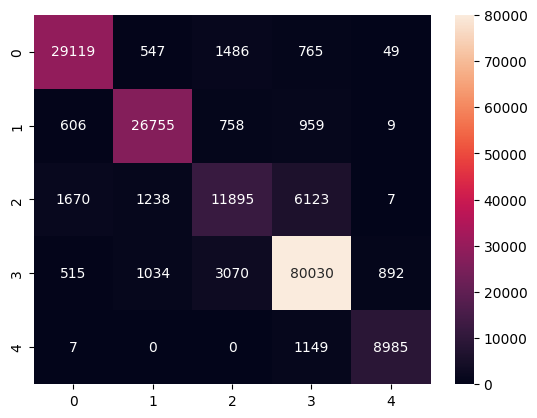

In [3]:

import pickle
import os
import numpy as np

save_dir = "/home/honeynaps/data/dataset/FEATURES/SLEEP_100_NOFILL"
x, y = [], []


saved_files = os.listdir(save_dir)
for file in saved_files:
    with open(os.path.join(save_dir, file), "rb") as f:
        data = pickle.load(f)
        x.append(data["x"])
        y.append(data["y"])

x = np.concatenate(x)
y = np.concatenate(y)

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

smote = SMOTE(sampling_strategy="auto", random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, random_state=42)

print(x_train.shape, y_train.shape)
print("--before--")
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))
x_train, y_train = smote.fit_resample(x_train, y_train)
print("--after--")
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

from xgboost import XGBClassifier

clf = XGBClassifier(n_estimators=500, random_state=42, tree_method="hist", device="cuda:2")
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
overall_acc = np.trace(cm) / np.sum(cm)
classwise_acc = np.diag(cm) / np.sum(cm, axis=1)

print("Overall Accuracy: ", overall_acc)
print("Classwise Accuracy: ", classwise_acc)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()


(177652, 843) (177652,)
--before--
(array([0, 1]), array([145522,  32130]))
(array([0, 1]), array([36561,  7872]))
--after--
(array([0, 1]), array([145522, 145522]))
(array([0, 1]), array([36561,  7872]))
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     36561
           1       0.91      0.86      0.88      7872

    accuracy                           0.96     44433
   macro avg       0.94      0.92      0.93     44433
weighted avg       0.96      0.96      0.96     44433

Overall Accuracy:  0.9593995453829361
Classwise Accuracy:  [0.98093597 0.859375  ]


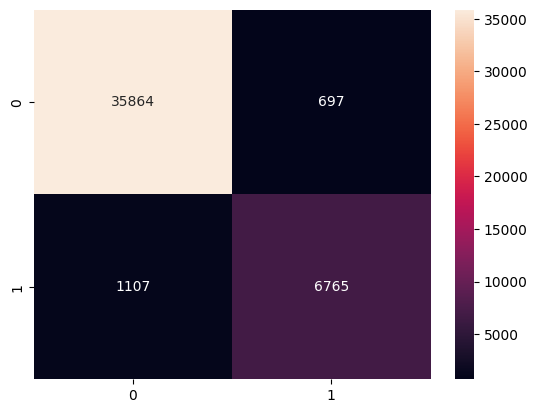

In [3]:
import natsort

import pickle
import os
import numpy as np

dataset_dir = "/home/honeynaps/data/dataset/FEATURES/SLEEP_100_NOFILL"

train_data_list  = []
train_label_list = []
val_data_list    = []
val_label_list   = []

np.random.seed(42)

file_names = natsort.natsorted(os.listdir(dataset_dir))
random_indices = np.random.permutation(len(file_names))
file_names = [file_names[i] for i in random_indices]

train_set_ratio = 0.8
train_files = file_names[:int(train_set_ratio*len(file_names))]
val_files = file_names[int(train_set_ratio*len(file_names)):]

for file_name in train_files:
    if file_name.endswith('.pickle'):
        with open(os.path.join(dataset_dir, file_name), 'rb') as f:
            data_dict = pickle.load(f)
            train_data_list.append(data_dict['x'].astype(np.float32))
            train_label_list.append(data_dict['y'])

for file_name in val_files:
    if file_name.endswith('.pickle'):
        with open(os.path.join(dataset_dir, file_name), 'rb') as f:
            data_dict = pickle.load(f)
            val_data_list.append(data_dict['x'].astype(np.float32))
            val_label_list.append(data_dict['y'])

# Combine data
x_train = np.concatenate(train_data_list)
y_train = np.concatenate(train_label_list)
x_test = np.concatenate(val_data_list)
y_test = np.concatenate(val_label_list)

# y 레이블이 0인 것은 1, 0이 아닌 것은 0으로 바꾸기
y_train = np.where(y_train == 0, 1, 0)
y_test = np.where(y_test == 0, 1, 0)

from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy="auto", random_state=42)

print(x_train.shape, y_train.shape)
print("--before--")
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))
# x_train, y_train = smote.fit_resample(x_train, y_train)
print("--after--")
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

import xgboost as xgb
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier

clf = XGBClassifier(n_estimators=2000, 
                    random_state=42, 
                    tree_method="hist", device="cuda:2")

clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
overall_acc = np.trace(cm) / np.sum(cm)
classwise_acc = np.diag(cm) / np.sum(cm, axis=1)

print("Overall Accuracy: ", overall_acc)
print("Classwise Accuracy: ", classwise_acc)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()
